<a href="https://colab.research.google.com/github/KavithaVeeraputhiran/Session-Based-psychometric-Risk-Detection-using-LSTM-with-SMOTE-enhanced-class-balancing/blob/main/Session_Based_psychometric_Risk_Detection_using_LSTM_with_SMOTE_enhanced_class_balancing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1.   List item
2.   List item



In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow


1.DATA-PREPROCESSING

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()


df = pd.read_csv(next(iter(uploaded)))
print(f"Shape: {df.shape}")
df.head()


Saving Features_Psychometric_Dataratio5.csv to Features_Psychometric_Dataratio5.csv
Shape: (4830, 28)


,Unnamed: 0,Date,User,O_norm,C_norm,E_norm,A_norm,N_norm,L1_norm,L2_norm,...,E3_norm,E4_norm,E5_norm,F1_norm,H1_norm,H2_norm,H3_norm,D1_norm,D2_norm,Class_Label
0,226554,29-11-2010,EHB0420,0.875,0.800,0.700,0.175,0.171429,0.000000,0.339506,...,0.250000,0.461476,0.344262,0.0,0.0,0.000000,0.210526,0.0,0.000000,0
1,299768,25-03-2011,PAD0773,0.650,0.275,0.100,0.150,0.685714,0.080310,0.232834,...,0.086957,0.289636,0.116667,0.0,0.0,0.218750,0.000000,0.0,0.000000,0
2,143648,26-07-2010,ADC0391,1.000,0.825,0.750,0.575,0.685714,0.000000,0.282138,...,0.440000,0.372237,0.327586,0.0,0.0,0.063830,0.000000,0.0,0.000000,0
3,145649,28-07-2010,GHH0288,0.050,0.650,0.750,0.650,0.457143,0.098795,0.147129,...,0.000000,0.301134,0.033898,0.0,0.0,0.000000,0.000000,0.0,0.142857,0
4,172354,07-09-2010,GQP0743,0.925,0.725,0.225,0.725,0.314286,0.010580,0.888491,...,0.531250,0.460582,0.266667,0.0,0.0,0.073171,0.066667,0.0,0.000000,0


In [ ]:
import pandas as pd


# Optional: View column names
print("Columns in DataFrame:", df.columns.tolist())

# Drop "Unnamed: 0" only if it exists
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Convert Date column safely
if "Date" in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
else:
    print("Warning: 'Date' column not found!")

# Show missing values
print("\nMissing Values:\n", df.isnull().sum())

# Describe dataset
print("\nDataset Description:")
print(df.describe(include='all'))

# Check and count class labels
if "Class_Label" in df.columns:
    print("\nClass label counts:")
    print(df['Class_Label'].value_counts())
else:
    print("Warning: 'Class_Label' column not found!")


Columns in DataFrame: ['Unnamed: 0', 'Date', 'User', 'O_norm', 'C_norm', 'E_norm', 'A_norm', 'N_norm', 'L1_norm', 'L2_norm', 'L3_norm', 'L4_norm', 'L5_norm', 'L6_norm', 'L7_norm', 'L8_norm', 'L9_norm', 'E1_norm', 'E3_norm', 'E4_norm', 'E5_norm', 'F1_norm', 'H1_norm', 'H2_norm', 'H3_norm', 'D1_norm', 'D2_norm', 'Class_Label']

Missing Values:
 Date           0
User           0
O_norm         0
C_norm         0
E_norm         0
A_norm         0
N_norm         0
L1_norm        0
L2_norm        0
L3_norm        0
L4_norm        0
L5_norm        0
L6_norm        0
L7_norm        0
L8_norm        0
L9_norm        0
E1_norm        0
E3_norm        0
E4_norm        0
E5_norm        0
F1_norm        0
H1_norm        0
H2_norm        0
H3_norm        0
D1_norm        0
D2_norm        0
Class_Label    0
dtype: int64

Dataset Description:
                                 Date     User       O_norm       C_norm  \
count                            4830     4830  4830.000000  4830.000000   
unique   

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])


df = df.sort_values(by=['User', 'Date'])

df['Day'] = df['Date'].dt.date


df['Session_ID'] = df['User'].astype(str) + "_" + df['Day'].astype(str)

sessions = dict(tuple(df.groupby('Session_ID')))


print("Total Sessions:", len(sessions))
print("Example session:")
sessions[list(sessions.keys())[0]].head()


Total Sessions: 4830
Example session:


,Date,User,O_norm,C_norm,E_norm,A_norm,N_norm,L1_norm,L2_norm,L3_norm,...,E5_norm,F1_norm,H1_norm,H2_norm,H3_norm,D1_norm,D2_norm,Class_Label,Day,Session_ID
1475,2010-01-26,AAE0190,0.65,0.5,0.1,1.0,0.428571,0.037543,0.321812,0.0,...,0.283333,0.0,0.0,0.066667,0.0,0.0,0.0,0,2010-01-26,AAE0190_2010-01-26


In [ ]:
def apply_temporal_rules(session_df):
    # Rule 1: High Neuroticism and Low Conscientiousness
    if session_df['N_norm'].mean() > 0.7 and session_df['C_norm'].mean() < 0.3:
        return 'High_Risk_Personality'

    # Rule 2: Frequent use of emotional words
    if session_df[['E3_norm', 'E4_norm', 'E5_norm']].mean().mean() > 0.5:
        return 'Emotional_Alert'

    return 'Normal'

# Apply to each session
session_risk_labels = {session_id: apply_temporal_rules(sdf) for session_id, sdf in sessions.items()}

# Convert to DataFrame
logic_df = pd.DataFrame(session_risk_labels.items(), columns=["Session_ID", "Logic_Label"])
logic_df.head()

# Merge session-level labels back into the main DataFrame
df = df.merge(logic_df, on='Session_ID', how='left')



2.SYNTHETIC DATA GENERATION


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

df = df.dropna(subset=["Class_Label"])

# Step 1: Separate features and label
X = df.drop("Class_Label", axis=1)
y = df["Class_Label"]

# Step 1.5: Keep only numeric columns in X
X = X.select_dtypes(include=[np.number])

# Step 1.6: Handle missing/infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]  # realign labels with cleaned features

# Step 2: Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Step 3: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ✅ Result
print("Original class distribution:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


Original class distribution: {0: 3091, 1: 773}
After SMOTE: {0: 3091, 1: 3091}


3.CREATING SEQUENCE


In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch


sequences = []
labels = []


feature_columns = [col for col in df.columns if col not in ['User', 'Date', 'Session_ID', 'Class_Label'] and df[col].dtype in [np.float64, np.int64]]

for session_id, session_df in df.groupby("Session_ID"):

    if session_df['Class_Label'].nunique() != 1:
        continue

    label = session_df['Class_Label'].iloc[0]
    features = session_df[feature_columns].values


    max_len = 10
    if len(features) >= max_len:
        features = features[:max_len]
    else:
        pad_len = max_len - len(features)
        features = np.pad(features, ((0, pad_len), (0, 0)), mode='constant')

    sequences.append(features)
    labels.append(label)


X_seq = torch.tensor(np.array(sequences), dtype=torch.float32)
y_seq = torch.tensor(np.array(labels), dtype=torch.long)


class SessionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, stratify=y_seq)

train_loader = DataLoader(SessionDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(SessionDataset(X_test, y_test), batch_size=32)


4.MODEL  TRAINING

Epoch 1/200 | Train Loss: 0.5438, Train Acc: 0.7704 | Test Loss: 0.4973, Test Acc: 0.8002
Epoch 2/200 | Train Loss: 0.4973, Train Acc: 0.7999 | Test Loss: 0.4943, Test Acc: 0.8002
Epoch 3/200 | Train Loss: 0.4801, Train Acc: 0.8012 | Test Loss: 0.3999, Test Acc: 0.8033
Epoch 4/200 | Train Loss: 0.3299, Train Acc: 0.8548 | Test Loss: 0.2974, Test Acc: 0.8675
Epoch 5/200 | Train Loss: 0.2923, Train Acc: 0.8670 | Test Loss: 0.3026, Test Acc: 0.8696
Epoch 6/200 | Train Loss: 0.2940, Train Acc: 0.8657 | Test Loss: 0.2815, Test Acc: 0.8685
Epoch 7/200 | Train Loss: 0.2783, Train Acc: 0.8716 | Test Loss: 0.2823, Test Acc: 0.8634
Epoch 8/200 | Train Loss: 0.2792, Train Acc: 0.8690 | Test Loss: 0.2740, Test Acc: 0.8872
Epoch 9/200 | Train Loss: 0.2771, Train Acc: 0.8768 | Test Loss: 0.2674, Test Acc: 0.8872
Epoch 10/200 | Train Loss: 0.2635, Train Acc: 0.8838 | Test Loss: 0.2656, Test Acc: 0.8810
Epoch 11/200 | Train Loss: 0.2759, Train Acc: 0.8797 | Test Loss: 0.2863, Test Acc: 0.8810
Epoch 12

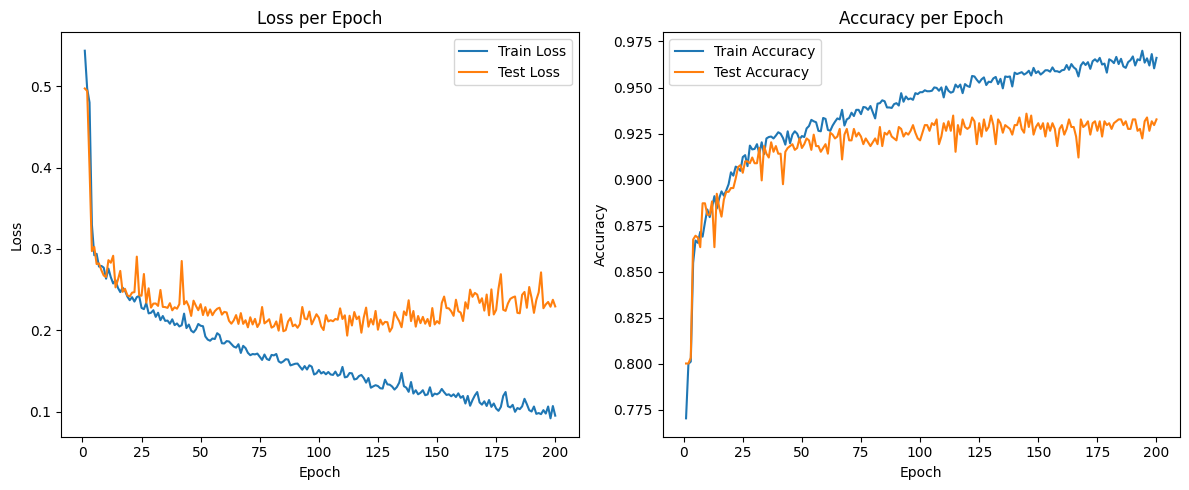


Classification Report:
              precision    recall  f1-score   support

           0     0.9585    0.9573    0.9579       773
           1     0.8299    0.8342    0.8320       193

    accuracy                         0.9327       966
   macro avg     0.8942    0.8958    0.8950       966
weighted avg     0.9328    0.9327    0.9328       966



In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

input_dim = X_train.shape[2]
hidden_dim = 64
num_layers = 2
num_classes = len(torch.unique(y_train))
model = LSTMClassifier(input_dim, hidden_dim, num_layers, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []


num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct_train / total_train

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == y_batch).sum().item()
            total_test += y_batch.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = correct_test / total_test

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.4f}")

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ====== Classification Report on Test Set ======
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))


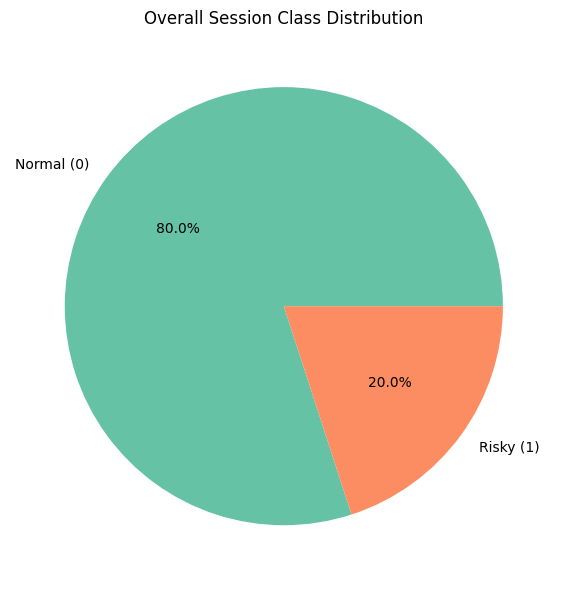

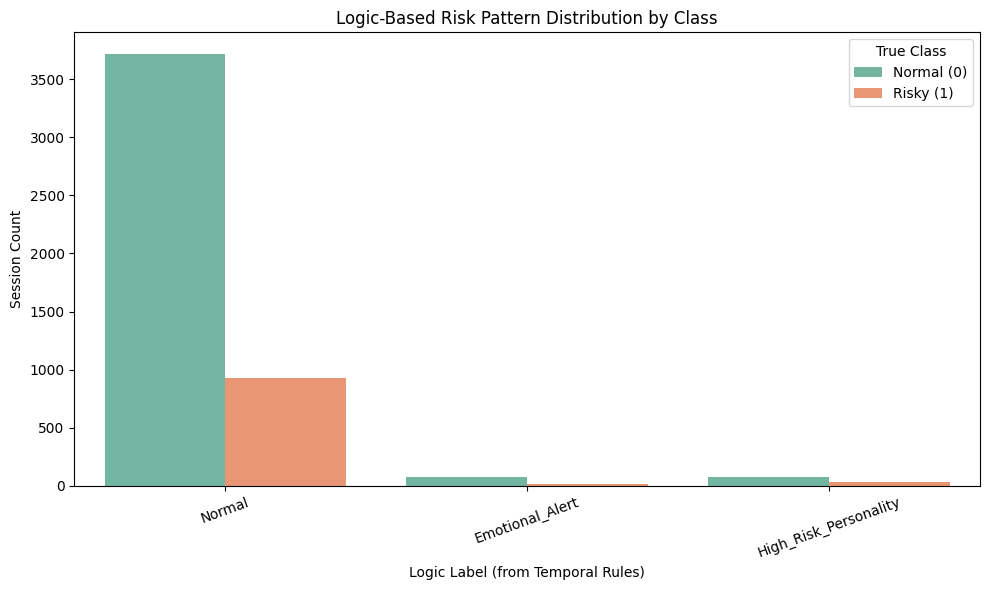

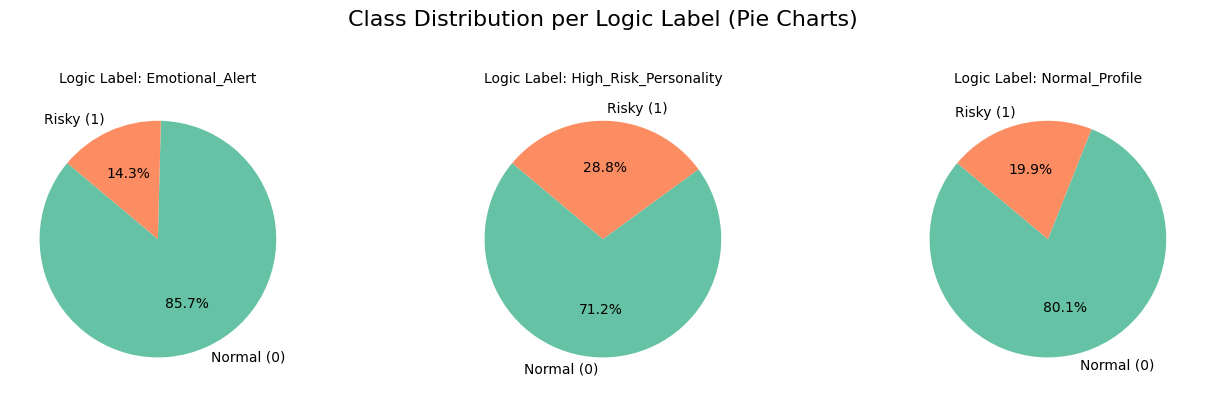

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df['Class_Label'] = df['Class_Label'].astype(int)

# ========== 1. OVERALL CLASS DISTRIBUTION (PIE) ==========
plt.figure(figsize=(6, 6))
class_counts = df['Class_Label'].value_counts().sort_index()
plt.pie(class_counts, labels=['Normal (0)', 'Risky (1)'], autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title('Overall Session Class Distribution')
plt.tight_layout()
plt.show()

# ========== 2. LOGIC LABEL vs RISK CLASS DISTRIBUTION (BAR PLOT) ==========
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Logic_Label', hue='Class_Label', palette='Set2')
plt.title('Logic-Based Risk Pattern Distribution by Class')
plt.xlabel('Logic Label (from Temporal Rules)')
plt.ylabel('Session Count')
plt.xticks(rotation=20)
plt.legend(title='True Class', labels=['Normal (0)', 'Risky (1)'])
plt.tight_layout()
plt.show()

# ========== 3. PER-LOGIC_LABEL PIE CHARTS ==========
logic_labels = sorted(df['Logic_Label'].unique())
# Optional: Rename 'Normal' logic label if it's too similar to class label
logic_labels = ['Normal_Profile' if lbl == 'Normal' else lbl for lbl in logic_labels]

cols = 3
rows = int(np.ceil(len(logic_labels) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
fig.suptitle('Class Distribution per Logic Label (Pie Charts)', fontsize=16)
axes = axes.flatten()
colors = sns.color_palette("Set2")

for i, logic in enumerate(logic_labels):
    ax = axes[i]
    subset = df[df['Logic_Label'] == (logic if logic != 'Normal_Profile' else 'Normal')]['Class_Label'].value_counts().sort_index()
    counts = [subset.get(0, 0), subset.get(1, 0)]
    labels = ['Normal (0)', 'Risky (1)']

    if sum(counts) > 0:
        ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
        ax.set_title(f'Logic Label: {logic}', fontsize=10)
    else:
        ax.axis('off')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# New Section

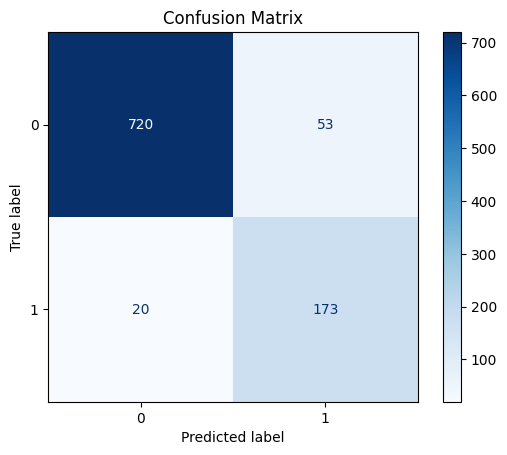

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt  # Make sure matplotlib is imported

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # Optional for better color
plt.title("Confusion Matrix")
plt.show()
